C:\Users\User\AppData\Local\Temp\ipykernel_25916\2755109030.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(boston_df['medv'], hist = True)


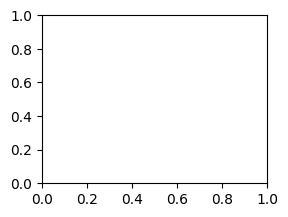

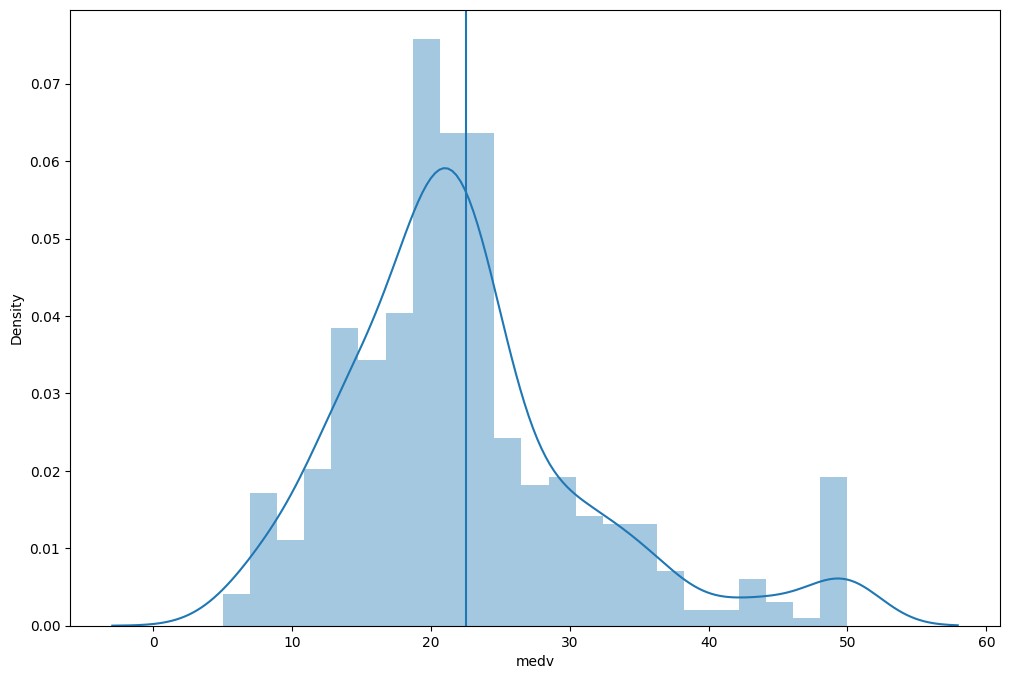

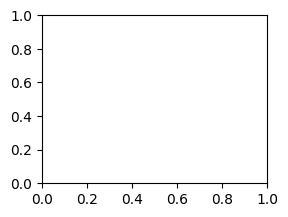

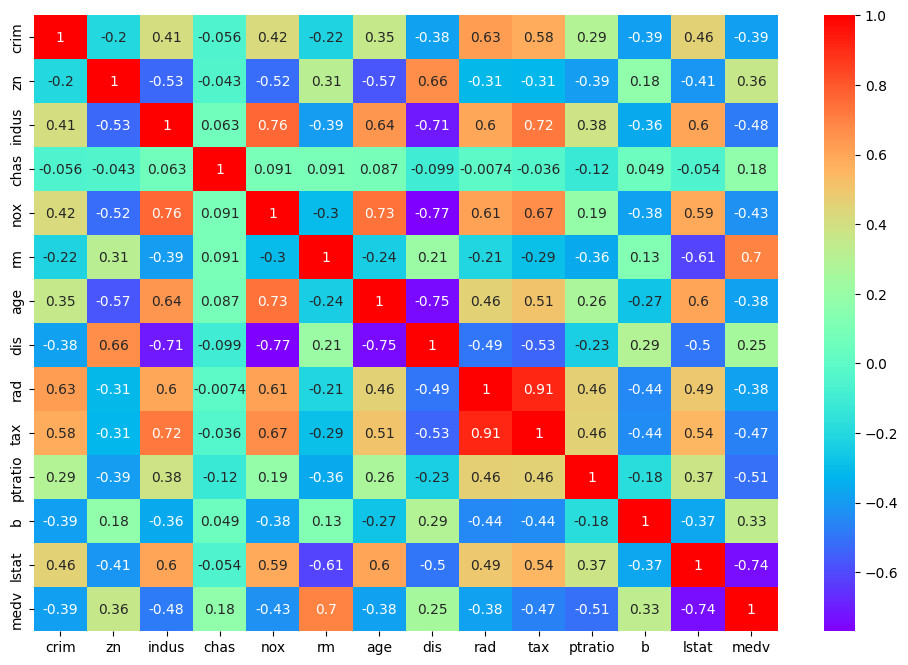

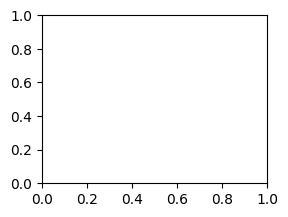

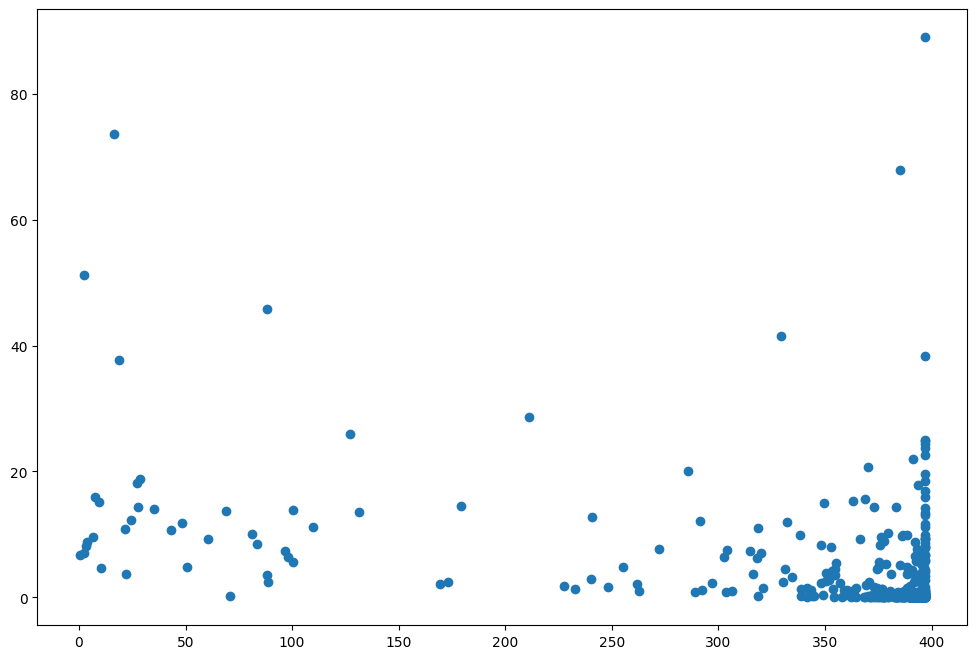

Intercept 25.393890808014312
Coefficient [ -7.97621994   5.83404095  -2.20220252   2.40292124  -6.61116763
  17.85494991   1.10868237 -16.60783904   0.67922997  -6.48614941
   4.12236805 -21.01163715]
[29.64514669 32.15324311 31.07138859 24.33834316 19.50368974]
Mean Absolute Error: 4.149481566579641
Mean Squared Error: 35.19426424736051
Root Mean Squared Error: 5.932475389528431


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
boston_df = pd.read_csv('https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv', sep = ",")
boston_df.head()
plt.subplot(2, 2, 1)
plt.figure(figsize=(12,8))
sns.distplot(boston_df['medv'], hist = True)
plt.axvline(boston_df['medv'].mean(), linestyle = '-')
plt.show()
plt.subplot(2, 2, 2)
plt.figure(figsize = (12,8))
sns.heatmap(boston_df.corr(), annot = True, cmap = 'rainbow')
plt.show()
plt.subplot(2, 2, 3)
plt.figure(figsize = (12,8))
plt.scatter(boston_df['b'], boston_df['crim'])
plt.show()
X = boston_df.drop(['rad', 'medv'], axis = 1)
Y = boston_df['medv']
#scaling

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range = (0,1))

X = scaler.fit_transform(X)
#test train split

from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state = 10)
#linear regression

from sklearn.linear_model import LinearRegression
lin_model = LinearRegression()
#model fit

lin_model.fit(X_train, Y_train)
print("Intercept", lin_model.intercept_)
print("Coefficient", lin_model.coef_)
#prediction
y_pred = lin_model.predict(X_test)
print(y_pred[:5])
from sklearn.metrics import mean_squared_error, mean_absolute_error

mae = mean_absolute_error(Y_test, y_pred)
mse = mean_squared_error(Y_test, y_pred)
rmse = np.sqrt(mse)
print(f"Mean Absolute Error: {mae}")
print(f"Mean Squared Error: {mse}")
print(f"Root Mean Squared Error: {rmse}")